# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [2]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'FCH4'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = False
LOG_TRANSFORM = True
ADD_ID = True
UNDERSAMPLE = False
ADD_TRT = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"83.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))

# Add trt variable
if ADD_TRT:
    data_main['trt'] = data_main['parcel'].map({'A': 0, 'B': 1}).fillna(0.5)

data_main

Loaded .parquet file 83.1.1_GapFillingDataset.parquet (1.432 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,SW_IN_POT,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain,RECO_NT_CUT_50_gfXG_parcelA_certain,GPP_NT_CUT_50_gfXG_parcelA_certain,...,RECO_NT_CUT_50_gfXG_certain_lag6h_roll9hmean,RECO_NT_CUT_50_gfXG_certain_lag9h_roll3hmean,RECO_NT_CUT_50_gfXG_certain_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_certain_lag9h_roll9hmean,GPP_NT_CUT_50_gfXG_certain_lag3h_roll3hsum,GPP_NT_CUT_50_gfXG_certain_lag3h_roll6hsum,GPP_NT_CUT_50_gfXG_certain_lag3h_roll9hsum,GPP_NT_CUT_50_gfXG_certain_lag6h_roll3hsum,GPP_NT_CUT_50_gfXG_certain_lag6h_roll6hsum,GPP_NT_CUT_50_gfXG_certain_lag6h_roll9hsum,GPP_NT_CUT_50_gfXG_certain_lag9h_roll3hsum,GPP_NT_CUT_50_gfXG_certain_lag9h_roll6hsum,GPP_NT_CUT_50_gfXG_certain_lag9h_roll9hsum,id,trt
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,B,certain,0.0,2.339872,2.339872,2.339872,2.339872,1.496309,-0.843563,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,B,certain,0.0,2.411913,2.411913,2.411913,2.411913,1.520340,-0.891574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,B,certain,0.0,2.129587,2.129587,2.129587,2.129587,1.515298,-0.614290,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1.0
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,B,certain,0.0,2.053106,2.053106,2.053106,2.053106,1.516559,-0.536547,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1.0
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,B,certain,0.0,1.897472,1.897472,1.897472,1.897472,1.512773,-0.384698,...,NaN,NaN,NaN,NaN,-0.07004,-0.07004,-0.07004,NaN,NaN,NaN,NaN,NaN,NaN,4,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,7.216800,7.216800,7.216800,7.216800,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27643,0.5
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,7.237069,7.237069,7.237069,7.237069,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27644,0.5
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,8.158186,8.158186,8.158186,8.158186,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27645,0.5


# CLEAN DATA

In [4]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

data

The target variable is FCH4_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 10.546895074946466


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,SW_IN_POT,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain,RECO_NT_CUT_50_gfXG_parcelA_certain,GPP_NT_CUT_50_gfXG_parcelA_certain,RECO_NT_CUT_50_gfXG_parcelB_certain,...,RECO_NT_CUT_50_gfXG_certain_lag6h_roll9hmean,RECO_NT_CUT_50_gfXG_certain_lag9h_roll3hmean,RECO_NT_CUT_50_gfXG_certain_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_certain_lag9h_roll9hmean,GPP_NT_CUT_50_gfXG_certain_lag3h_roll3hsum,GPP_NT_CUT_50_gfXG_certain_lag3h_roll6hsum,GPP_NT_CUT_50_gfXG_certain_lag3h_roll9hsum,GPP_NT_CUT_50_gfXG_certain_lag6h_roll3hsum,GPP_NT_CUT_50_gfXG_certain_lag6h_roll6hsum,GPP_NT_CUT_50_gfXG_certain_lag6h_roll9hsum,GPP_NT_CUT_50_gfXG_certain_lag9h_roll3hsum,GPP_NT_CUT_50_gfXG_certain_lag9h_roll6hsum,GPP_NT_CUT_50_gfXG_certain_lag9h_roll9hsum,id,trt
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,NaN,NaN,-3.231648,B,certain,0.000,2.339872,2.339872,2.339872,2.339872,1.496309,-0.843563,1.496309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0
2023-11-08 02:15:00,NaN,0.358358,NaN,0.358358,3.168362,B,certain,0.000,1.897472,1.897472,1.897472,1.897472,1.512773,-0.384698,1.512773,...,NaN,NaN,NaN,NaN,-0.070040,-0.070040,-0.070040,NaN,NaN,NaN,NaN,NaN,NaN,4,1.0
2023-11-08 02:45:00,NaN,0.205127,NaN,NaN,8.004995,B,certain,0.000,1.644457,1.644457,1.644457,1.644457,1.508982,-0.135474,1.508982,...,NaN,NaN,NaN,NaN,-0.136161,-0.136161,-0.136161,NaN,NaN,NaN,NaN,NaN,NaN,5,1.0
2023-11-08 03:15:00,NaN,0.070120,NaN,0.070120,-3.270484,B,certain,0.000,1.554488,1.554488,1.554488,1.554488,1.498848,-0.055640,1.498848,...,NaN,NaN,NaN,NaN,-0.979724,-0.979724,-0.979724,NaN,NaN,NaN,NaN,NaN,NaN,6,1.0
2023-11-08 05:15:00,NaN,0.149151,NaN,0.149151,-12.813660,B,certain,0.000,1.427298,1.427298,1.427298,1.427298,1.484854,0.057555,1.484854,...,1.498848,NaN,NaN,NaN,-3.336793,-3.406833,-3.406833,-0.07004,-0.07004,-0.07004,NaN,NaN,NaN,10,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 13:45:00,-20.456192,-0.340064,-20.456192,-0.340064,11.606270,A,certain,1144.190,-20.310053,-16.886749,-20.310053,-16.886749,NaN,NaN,NaN,...,NaN,NaN,NaN,8.919043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.708568,27579,0.0
2025-06-04 15:15:00,-10.791690,-0.213525,-10.791690,-0.213525,11.790242,A,uncertain,963.553,-11.432091,-10.368332,-11.432091,-10.368332,NaN,NaN,NaN,...,NaN,NaN,NaN,8.768273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.642708,27582,0.0
2025-06-04 15:45:00,-14.573490,NaN,-14.573490,NaN,-21.838654,A,uncertain,881.604,-12.242549,-11.079562,-12.242549,-11.079562,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27583,0.0


# SELECT FEATURES

In [5]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# 'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_U50_f_reddyproc_roll3hsum'
# ]

# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data

,SW_IN_POT,timesince_prec,wfps_0.15_gfXG,ts_0.15_gfXG_lag6h,ts_0.3_gfXG_lag3h,wfps_0.3_gfXG_lag6h,prec_roll6hsum,prec_roll9hsum,ta_roll3hmean,ta_roll6hmean,ts_0.05_gfXG_roll3hmean,ts_0.05_gfXG_roll6hmean,ts_0.05_gfXG_roll9hmean,ts_0.15_gfXG_roll3hmean,ts_0.15_gfXG_roll9hmean,...,ts_0.05_gfXG_diff12h,ts_0.05_gfXG_diff24h,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff12h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,id,trt,FCH4_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,0.000,12.0,55.128997,11.300447,10.864449,44.409653,0.000,1.400,5.572222,5.858333,7.314724,7.836772,8.474789,10.757845,11.117871,...,-3.222614,-2.857585,-1.485105,-1.116706,-1.152150,-0.275176,2.956382,0.684108,-0.193433,-0.188894,0.055964,-1.641550,0,1.0,-3.231648
2023-11-08 02:15:00,0.000,16.0,55.228593,11.324962,11.600913,43.695390,0.000,0.700,5.688889,5.763889,6.964170,7.288305,7.792853,9.927642,10.783552,...,-3.571157,-1.277978,-1.522183,-1.730865,-1.054997,0.243881,1.087768,0.750873,-0.187335,-0.028905,0.178615,-0.724348,4,1.0,3.168362
2023-11-08 02:45:00,0.000,17.0,55.221686,11.252397,11.808778,42.929763,0.000,0.500,5.738889,5.716667,6.981580,7.217316,7.678477,9.794981,10.700752,...,-3.509627,-0.654539,-1.534524,-1.624041,-1.351854,-0.060042,0.728571,0.741690,-0.208016,-0.018750,0.245680,0.083496,5,1.0,8.004995
2023-11-08 03:15:00,0.000,18.0,55.221308,11.290299,10.908412,42.908743,0.000,0.000,5.750000,5.661111,7.040911,7.177818,7.571485,9.788431,10.616063,...,-3.156895,-0.601441,-1.514255,-1.743717,-1.250376,-0.069672,0.609105,0.507260,-0.005498,-0.069987,0.059082,0.121729,6,1.0,-3.270484
2023-11-08 05:15:00,0.000,22.0,55.272922,10.543236,11.114241,42.564296,0.000,0.000,5.150000,5.419444,7.028110,6.996140,7.201573,9.897497,10.317301,...,-2.950659,-0.995625,-0.546853,-1.199464,-0.454482,-0.891764,-0.625095,0.935342,0.146175,0.122429,0.018764,0.876177,10,1.0,-12.813660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 13:45:00,1144.190,0.0,49.962609,17.700000,16.901111,46.307756,0.340,0.816,20.288889,19.014722,21.202314,19.864213,18.941882,18.214074,17.936574,...,4.199999,-3.603890,0.796666,-0.190556,-0.637778,-0.110000,0.181666,-0.638614,-0.317905,-0.502228,-1.270117,-0.792418,27579,0.0,11.606270
2025-06-04 15:15:00,963.553,0.0,49.906177,17.700000,16.900000,46.165194,1.445,1.615,20.186667,19.921111,22.022036,20.933194,19.802654,18.564537,18.064290,...,4.509443,-2.886112,1.138889,0.438889,-0.907222,0.020556,0.021112,-0.850742,-0.351766,-0.484698,-1.147036,-0.822825,27582,0.0,11.790242
2025-06-04 15:45:00,881.604,0.0,49.867204,17.700000,16.901667,46.110390,2.023,2.193,20.130000,20.100556,22.059443,21.202129,20.061296,18.667685,18.123642,...,4.453888,-2.397222,1.201111,0.591667,-0.957222,0.113333,0.056667,-0.921131,-0.362535,-0.519756,-1.143853,-0.820757,27583,0.0,-21.838654


# IMBALANCE HANDLING

## UNDER SAMPLING

In [6]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.')
    plt.show()

## LOG TRANSFORMATION

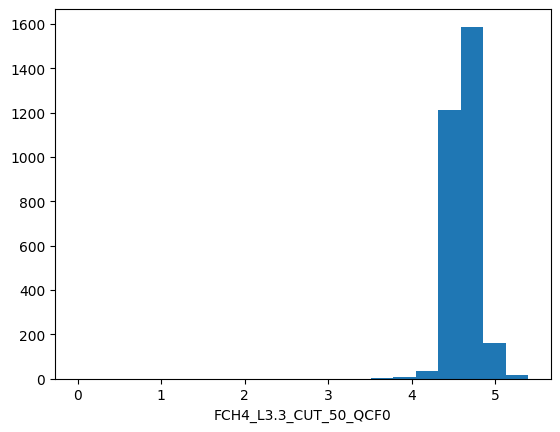

,SW_IN_POT,timesince_prec,wfps_0.15_gfXG,ts_0.15_gfXG_lag6h,ts_0.3_gfXG_lag3h,wfps_0.3_gfXG_lag6h,prec_roll6hsum,prec_roll9hsum,ta_roll3hmean,ta_roll6hmean,ts_0.05_gfXG_roll3hmean,ts_0.05_gfXG_roll6hmean,ts_0.05_gfXG_roll9hmean,ts_0.15_gfXG_roll3hmean,ts_0.15_gfXG_roll9hmean,...,ts_0.05_gfXG_diff12h,ts_0.05_gfXG_diff24h,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff12h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,id,trt,FCH4_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,0.000,12.0,55.128997,11.300447,10.864449,44.409653,0.000,1.400,5.572222,5.858333,7.314724,7.836772,8.474789,10.757845,11.117871,...,-3.222614,-2.857585,-1.485105,-1.116706,-1.152150,-0.275176,2.956382,0.684108,-0.193433,-0.188894,0.055964,-1.641550,0,1.0,4.548914
2023-11-08 02:15:00,0.000,16.0,55.228593,11.324962,11.600913,43.695390,0.000,0.700,5.688889,5.763889,6.964170,7.288305,7.792853,9.927642,10.783552,...,-3.571157,-1.277978,-1.522183,-1.730865,-1.054997,0.243881,1.087768,0.750873,-0.187335,-0.028905,0.178615,-0.724348,4,1.0,4.614424
2023-11-08 02:45:00,0.000,17.0,55.221686,11.252397,11.808778,42.929763,0.000,0.500,5.738889,5.716667,6.981580,7.217316,7.678477,9.794981,10.700752,...,-3.509627,-0.654539,-1.534524,-1.624041,-1.351854,-0.060042,0.728571,0.741690,-0.208016,-0.018750,0.245680,0.083496,5,1.0,4.661232
2023-11-08 03:15:00,0.000,18.0,55.221308,11.290299,10.908412,42.908743,0.000,0.000,5.750000,5.661111,7.040911,7.177818,7.571485,9.788431,10.616063,...,-3.156895,-0.601441,-1.514255,-1.743717,-1.250376,-0.069672,0.609105,0.507260,-0.005498,-0.069987,0.059082,0.121729,6,1.0,4.548503
2023-11-08 05:15:00,0.000,22.0,55.272922,10.543236,11.114241,42.564296,0.000,0.000,5.150000,5.419444,7.028110,6.996140,7.201573,9.897497,10.317301,...,-2.950659,-0.995625,-0.546853,-1.199464,-0.454482,-0.891764,-0.625095,0.935342,0.146175,0.122429,0.018764,0.876177,10,1.0,4.442036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 13:45:00,1144.190,0.0,49.962609,17.700000,16.901111,46.307756,0.340,0.816,20.288889,19.014722,21.202314,19.864213,18.941882,18.214074,17.936574,...,4.199999,-3.603890,0.796666,-0.190556,-0.637778,-0.110000,0.181666,-0.638614,-0.317905,-0.502228,-1.270117,-0.792418,27579,0.0,4.694715
2025-06-04 15:15:00,963.553,0.0,49.906177,17.700000,16.900000,46.165194,1.445,1.615,20.186667,19.921111,22.022036,20.933194,19.802654,18.564537,18.064290,...,4.509443,-2.886112,1.138889,0.438889,-0.907222,0.020556,0.021112,-0.850742,-0.351766,-0.484698,-1.147036,-0.822825,27582,0.0,4.696396
2025-06-04 15:45:00,881.604,0.0,49.867204,17.700000,16.901667,46.110390,2.023,2.193,20.130000,20.100556,22.059443,21.202129,20.061296,18.667685,18.123642,...,4.453888,-2.397222,1.201111,0.591667,-0.957222,0.113333,0.056667,-0.921131,-0.362535,-0.519756,-1.143853,-0.820757,27583,0.0,4.329716


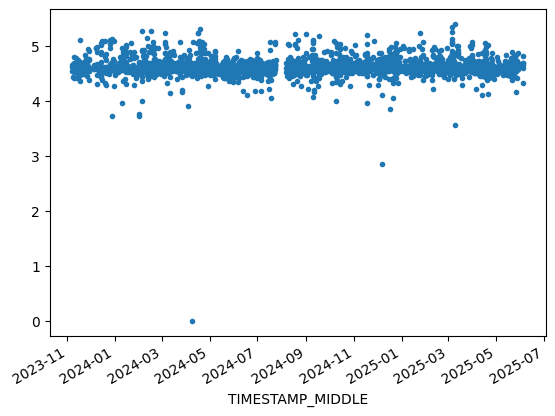

In [7]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

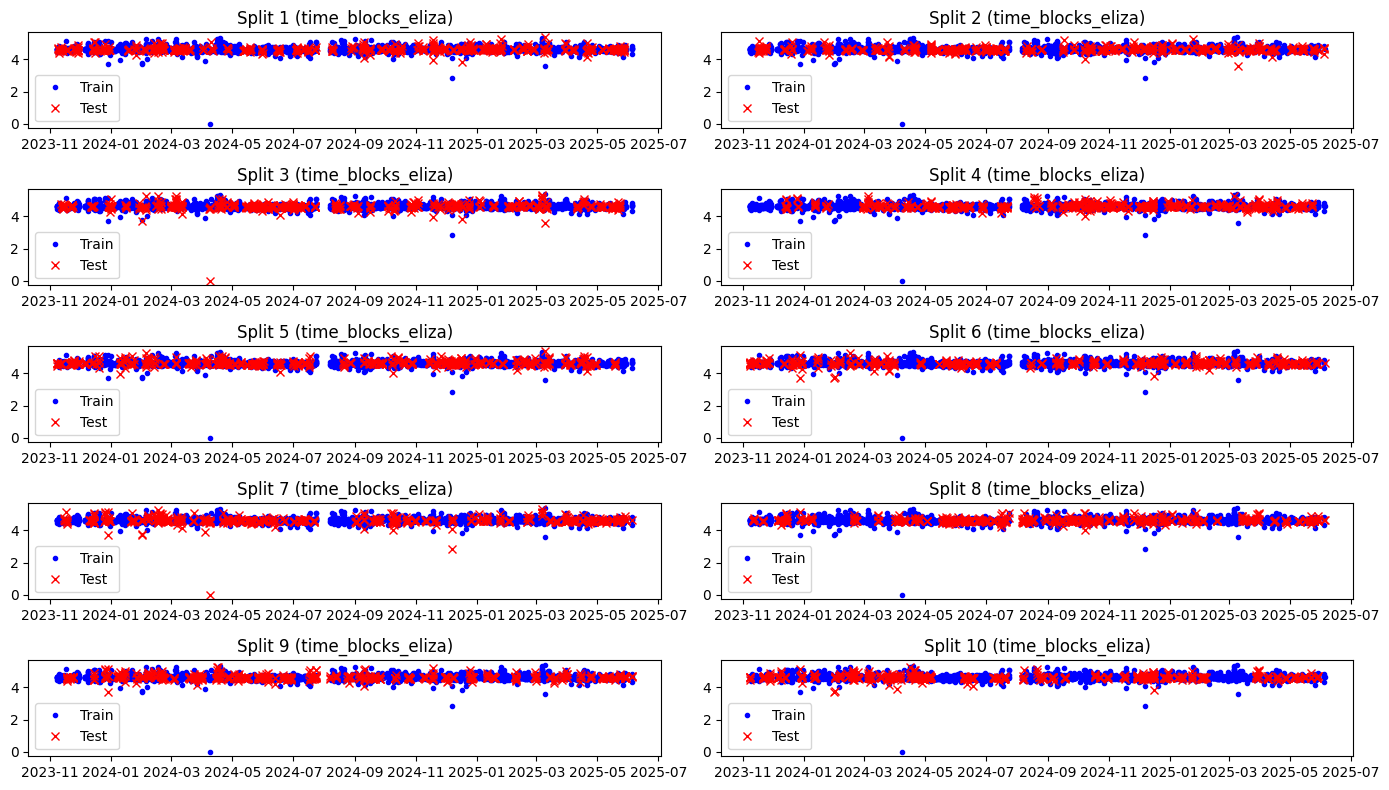

In [8]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block = 6, min_block=1, random_state=42): # you can set mean block to median_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits
    
if CROSSVAL_SPLIT == 'custom_time_blocks':
    def create_splits(X, y, n_folds=5, test_fraction=0.2, block_duration='1D',
                    min_gap='6D', buffer_gap='1D', seed=None):
        """
        Time-block CV with buffer and min_gap enforcement, allowing partial blocks to match test_fraction.
        """
        if seed is not None:
            np.random.seed(seed)

        total_rows = len(X)
        total_test_target = int(total_rows * test_fraction)
        all_times = X.index
        block_dur = pd.to_timedelta(block_duration)
        min_gap_dur = pd.to_timedelta(min_gap)
        buffer_gap_dur = pd.to_timedelta(buffer_gap)

        # Generate all possible block start times
        possible_starts = all_times[(all_times + block_dur) <= all_times[-1]]
        splits = []

        for fold in range(n_folds):
            test_indices = set()
            buffer_indices = set()
            selected_blocks = []

            shuffled_starts = np.random.permutation(possible_starts)

            for start_time in shuffled_starts:
                end_time = start_time + block_dur
                buffer_start = start_time - buffer_gap_dur
                buffer_end = end_time + buffer_gap_dur

                # Enforce min_gap between selected test blocks
                if any(abs(pd.Timedelta(start_time - sel).total_seconds()) < min_gap_dur.total_seconds()
                    for sel in selected_blocks):
                    continue

                block_mask = (all_times >= start_time) & (all_times < end_time)
                buffer_mask = (all_times >= buffer_start) & (all_times < buffer_end)

                block_idx = np.where(block_mask)[0]
                buffer_idx = np.where(buffer_mask)[0]

                if len(block_idx) == 0:
                    continue

                # Allow trimming final block if needed
                remaining = total_test_target - len(test_indices)
                if remaining <= 0:
                    break
                if len(block_idx) > remaining:
                    block_idx = block_idx[:remaining]

                # Check again for overlap with buffer
                if any(i in buffer_indices for i in block_idx):
                    continue

                test_indices.update(block_idx)
                buffer_indices.update(buffer_idx)
                selected_blocks.append(start_time)

                if len(test_indices) >= total_test_target:
                    break

            train_indices = sorted(set(range(total_rows)) - test_indices - buffer_indices)
            splits.append((np.array(train_indices), np.array(sorted(test_indices))))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING

In [9]:
# Convert cross-val splits into PredefinedSplit format to be able to use them in GridSearchCV
test_fold = np.full(len(data), -1)  # Initialize with -1 (all as training)
for fold_idx, (train_idx, test_idx) in enumerate(cross_val_splits):
    test_fold[test_idx] = fold_idx  # Assign test samples to a specific fold
predefined_cv = PredefinedSplit(test_fold)

param_grids = {
    'RandomForest': {
        'n_estimators': [50, 100, 300, 500], # Similar to XGBoost
        'max_depth': [3, 5, 10, 15], # Controls tree depth
        'min_samples_split': [2, 5, 10], # Similar to min_child_weight
        'min_samples_leaf': [1, 3, 5], # Controls leaf size
        'max_features': [0.4, 0.6, 0.8, 1.0], # Similar to colsample_bytree
    },
    'XGBoost': {
        'n_estimators': [50, 100, 300, 500],
        'gamma': [0, 0.2, 0.4],
        'max_depth': [3, 5, 10, 15],
        'learning_rate': [0.001, 0.005, 0.01, 0.05],
        'subsample': [0.65, 0.75, 1],
        'colsample_bytree': [0.4, 0.6, 0.8, 1],
        'min_child_weight': [2, 5, 10]
    }
}

model_class = RandomForestRegressor if MODEL_TYPE == 'RandomForest' else XGBRegressor
param_grid = param_grids[MODEL_TYPE]
model = model_class(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=predefined_cv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(data[selected_features], data[TARGET])

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.005, 'max_depth': 15, 'min_child_weight': 2, 'n_estimators': 300, 'subsample': 0.65}


# EXPORT 

In [10]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(grid_search.best_params_, f)

# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-10-24 23:53:11
